#  carte_mineralogique
## creation d'une carte mineralogique a partir de 11 fichier



In [3]:
import os
os.chdir('/home/maxgoat/projet') 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


class ElementMap:
    """Charge et stocke la matrice 2D d'un élément (ex: Si, Fe...)"""
    def __init__(self, element_name, filepath):
        self.name = element_name
        self.matrix = None
        self.load_files(filepath)

        
    def load_files(self,path):
        """charge un fichier en txt en array """
        with open(path, "r", encoding="utf-8") as f:
            lignes = [ligne.strip() for ligne in f]
        data = []
        for ligne in lignes:
            valeurs = [int(x) for x in ligne.split(";")]
            data.append(valeurs)
        
        self.matrix = np.array(data)
    
    def __repr__(self):
        return f"ElementMap({self.name}, shape={self.matrix.shape})"



    
    def __repr__(self):
        return f"ElementMap({self.name}, shape={self.matrix.shape})"




class MineralMap:
    """Contient tous les ElementMap + fait la classification"""
    def __init__(self):
        self.elements = {}  
    
    def load_element(self, name, path):
        """Charge un élément et le stocke dans self.elements"""
        self.elements[name] = ElementMap(name,path)
    
    def normalize(self):
        """Normalise les comptes bruts → proportions par pixel"""
        stack = np.stack([self.elements[e].matrix for e in ["Si","Ti","Al","Fe","Mn","Mg","Ca","Na","K","O","P"]], axis=2)
        somme = stack.sum(axis=2)
        somme_safe = np.where(somme == 0, 1, somme) #eviter division par zeero
        self.normalise = stack / somme_safe[:, :, np.newaxis]
    
        
    def classify(self):
        """Pour chaque pixel → trouve le minéral le plus proche"""
        noms = list(MINERAUX.keys())        
        compositions = np.array(list(MINERAUX.values()))  
        
        self.carte = np.zeros((768, 1024), dtype=int)
        
        for i in range(768):
            for j in range(1024):
                pixel = self.normalise[i, j, :]          
                distances = np.sqrt(np.sum((compositions - pixel)**2, axis=1))
                self.carte[i, j] = np.argmin(distances)
            
class MineralMapper:
    """Gère la visualisation et l'export de la carte"""
    def __init__(self, mineral_map):
        self.mineral_map = mineral_map

    def plot(self):
        noms = list(MINERAUX.keys())
        image = np.zeros((768, 1024, 3))
        couleurs = np.array(list(COULEURS.values()))  
        for i in range(768):
            for j in range(1024):
                image[i, j] = couleurs[self.mineral_map.carte[i, j]]
        plt.imshow(image)




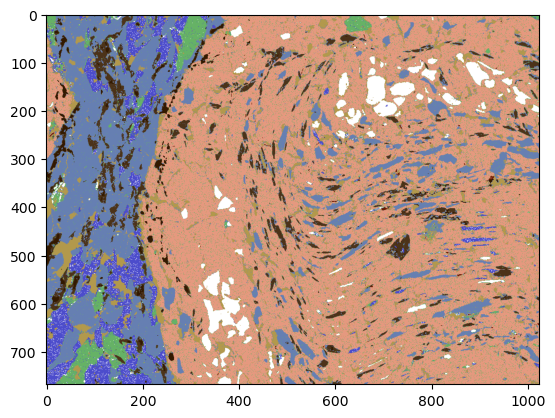

In [5]:
mm = MineralMap()
mm.load_element("Si", "CHA(1,8)_Si-K.txt")
mm.load_element("Ti", "CHA(1,8)_Ti-Kα.txt")
mm.load_element("Al", "CHA(1,8)_Al-K.txt")
mm.load_element("Fe", "CHA(1,8)_Fe-Kα.txt")
mm.load_element("Mn", "CHA(1,8)_Mn-Kα.txt")
mm.load_element("Mg", "CHA(1,8)_Mg-K.txt")
mm.load_element("Ca", "CHA(1,8)_Ca-Kα.txt")
mm.load_element("Na", "CHA(1,8)_Na-Kα.txt")
mm.load_element("K",  "CHA(1,8)_K-Kα.txt")
mm.load_element("O",  "CHA(1,8)_O-Kα.txt")
mm.load_element("P",  "CHA(1,8)_P-Kα.txt")

MINERAUX = {
    "Quartz":      [0.333, 0,     0,     0,     0,     0,     0,     0,     0,     0.667, 0],
    "Rutile":      [0,     0.333, 0,     0,     0,     0,     0,     0,     0,     0.667, 0],
    "Hematite":    [0,     0,     0,     0.400, 0,     0,     0,     0,     0,     0.600, 0],
    "Glaucophane": [0.210, 0,     0.044, 0.038, 0,     0.052, 0.004, 0.047, 0,     0.605, 0],
    "Omphacite":   [0.212, 0,     0.038, 0.035, 0,     0.006, 0.048, 0.055, 0,     0.606, 0],
    "Epidote":     [0.133, 0,     0.100, 0.049, 0,     0.032, 0.087, 0,     0,     0.600, 0],
    "Grenat":      [0.150, 0,     0.096, 0.093, 0.014, 0.008, 0.039, 0,     0,     0.600, 0],
    "Muscovite":   [0.189, 0,     0.114, 0.012, 0,     0.020, 0,     0.002, 0.053, 0.609, 0],
    "Sphere":      [0.125, 0.125, 0,     0,     0,     0,     0.125, 0,     0,     0.625, 0],
}


COULEURS = {
    "Quartz":      [1.0,  1.0,  1.0],
    "Rutile":      [0.2,  0.1,  0.0],
    "Hematite":    [0.4,  0.1,  0.0],
    "Glaucophane": [0.3,  0.3,  0.8],
    "Omphacite":   [0.4,  0.7,  0.4],
    "Epidote":     [0.4,  0.5,  0.7],
    "Grenat":      [0.9,  0.6,  0.5],
    "Muscovite":   [0.7,  0.6,  0.3],
    "Sphere":      [0.3,  0.2,  0.1],
}


mm.normalize()
mm.classify()
noms = list(MINERAUX.keys())
mapper = MineralMapper(mm)
mapper.plot()

